
## Preparing final dataset for further use in machine learning algorithms 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df = pd.read_csv('/Users/devammpatel/Desktop/Supervised ML Project on Airbnb Dataset/Dataset/Airbnb_Open_Data_Cleaned.csv')
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country code,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,US,...,193.0,10.0,9.0,10/19/2021,0.210000,4.0,6.0,96.0,Clean up and treat the home the way you'd like...,No license
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,US,...,28.0,3.0,45.0,5/21/2022,0.380000,4.0,2.0,96.0,Pet friendly but please confirm with me if the...,No license
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.80902,-73.94190,US,...,124.0,3.0,0.0,9/9/2021,1.376597,5.0,1.0,96.0,"I encourage you to use my kitchen, cooking and...",No license
3,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,US,...,41.0,10.0,9.0,11/19/2018,0.100000,3.0,1.0,96.0,"Please no smoking in the house, porch or on th...",No license
4,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,US,...,115.0,3.0,74.0,6/22/2019,0.590000,3.0,1.0,96.0,"No smoking, please, and no drugs.",No license


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101368 entries, 0 to 101367
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              101368 non-null  int64  
 1   NAME                            101368 non-null  str    
 2   host id                         101368 non-null  int64  
 3   host_identity_verified          101368 non-null  str    
 4   host name                       101368 non-null  str    
 5   neighbourhood group             101368 non-null  str    
 6   neighbourhood                   101368 non-null  str    
 7   lat                             101368 non-null  float64
 8   long                            101368 non-null  float64
 9   country code                    101368 non-null  str    
 10  instant_bookable                101368 non-null  bool   
 11  cancellation_policy             101368 non-null  str    
 12  room type                  

Let's drop unwanted columns 

In [7]:
#Dropping the 'id', 'host id', 'NAME', 'host name', 'country code', 'reviews per month', 'house_rules', 'license' columns as they are not useful for our analysis
df.drop(['id', 'host id', 'NAME', 'host name', 'country code', 'reviews per month', 'house_rules', 'license'], axis=1, inplace=True)
df.head()

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,966.0,193.0,10.0,9.0,10/19/2021,4.0,6.0,96.0
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142.0,28.0,3.0,45.0,5/21/2022,4.0,2.0,96.0
2,unconfirmed,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,620.0,124.0,3.0,0.0,9/9/2021,5.0,1.0,96.0
3,verified,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,204.0,41.0,10.0,9.0,11/19/2018,3.0,1.0,96.0
4,verified,Manhattan,Murray Hill,40.74767,-73.97500,True,flexible,Entire home/apt,2013.0,577.0,115.0,3.0,74.0,6/22/2019,3.0,1.0,96.0


Now that we are left with only useful data, let's encode the categorical data using onehotencoding technique and numerical data using standardscaler.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101368 entries, 0 to 101367
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          101368 non-null  str    
 1   neighbourhood group             101368 non-null  str    
 2   neighbourhood                   101368 non-null  str    
 3   lat                             101368 non-null  float64
 4   long                            101368 non-null  float64
 5   instant_bookable                101368 non-null  bool   
 6   cancellation_policy             101368 non-null  str    
 7   room type                       101368 non-null  str    
 8   Construction year               101368 non-null  float64
 9   price                           101368 non-null  float64
 10  service fee                     101368 non-null  float64
 11  minimum nights                  101368 non-null  float64
 12  number of reviews          

In [9]:
categorical_cols = ['neighbourhood group', 'neighbourhood', 'room type', 'host_identity_verified', 'cancellation_policy', 'last review']  # list string columns
for col in categorical_cols:
    df[col] = df[col].astype('object')

In [10]:
# Printing the number of numerical and categorical features in the dataset along with their names
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f'Number of numerical features: {len(numerical_cols)}')
print(f'Numerical features: {numerical_cols.tolist()}')
categorical_cols = df.select_dtypes(include=['object']).columns
print(f'Number of categorical features: {len(categorical_cols)}')
print(f'Categorical features: {categorical_cols.tolist()}')

Number of numerical features: 10
Numerical features: ['lat', 'long', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'review rate number', 'calculated host listings count', 'availability 365']
Number of categorical features: 6
Categorical features: ['host_identity_verified', 'neighbourhood group', 'neighbourhood', 'cancellation_policy', 'room type', 'last review']


### Before applying encoding, we will first separate dataset into train and test 

In [11]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']

In [12]:
X.head()

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,service fee,minimum nights,number of reviews,last review,review rate number,calculated host listings count,availability 365
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,193.0,10.0,9.0,10/19/2021,4.0,6.0,96.0
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,28.0,3.0,45.0,5/21/2022,4.0,2.0,96.0
2,unconfirmed,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,124.0,3.0,0.0,9/9/2021,5.0,1.0,96.0
3,verified,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,41.0,10.0,9.0,11/19/2018,3.0,1.0,96.0
4,verified,Manhattan,Murray Hill,40.74767,-73.97500,True,flexible,Entire home/apt,2013.0,115.0,3.0,74.0,6/22/2019,3.0,1.0,96.0


In [13]:
y

0          966.0
1          142.0
2          620.0
3          204.0
4          577.0
           ...  
101363     696.0
101364     909.0
101365     387.0
101366     848.0
101367    1128.0
Name: price, Length: 101368, dtype: float64

In [14]:
#Separating the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((81094, 16), (20274, 16), (81094,), (20274,))

In [16]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 101368 entries, 0 to 101367
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   host_identity_verified          101368 non-null  object 
 1   neighbourhood group             101368 non-null  object 
 2   neighbourhood                   101368 non-null  object 
 3   lat                             101368 non-null  float64
 4   long                            101368 non-null  float64
 5   instant_bookable                101368 non-null  bool   
 6   cancellation_policy             101368 non-null  object 
 7   room type                       101368 non-null  object 
 8   Construction year               101368 non-null  float64
 9   service fee                     101368 non-null  float64
 10  minimum nights                  101368 non-null  float64
 11  number of reviews               101368 non-null  float64
 12  last review                

In [17]:
# Creating column transformer for encoding categorical features and scaling numerical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])  

In [18]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [19]:
# Applying transformation on training data 
X_train = preprocessor.fit_transform(X_train)

In [20]:
X_train = X_train.toarray()  # Convert sparse matrix to dense array
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,2648,2649,2650,2651,2652,2653,2654,2655,2656,2657
0,-0.012430,-0.666344,-1.126198,1.053917,-0.424904,-0.711476,-1.777550,-0.214345,-1.273123,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.537480,-0.410371,-1.126198,0.163474,-0.424904,-0.575155,0.560375,-0.214345,-1.273123,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.363149,0.020752,0.435330,-0.862799,0.052739,-0.484275,-0.998241,-0.121919,-0.687504,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.057824,-0.905589,-0.258682,-0.123279,0.052739,-0.666035,0.560375,-0.152728,-1.273123,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.466351,1.286307,0.435330,1.114286,-0.424904,-0.075314,1.339684,-0.214345,-1.254823,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81089,-1.241998,-0.247516,-0.779191,-1.194829,1.485667,-0.257074,-1.777550,-0.214345,0.483736,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81090,-0.127702,-0.839882,-0.779191,0.797349,-0.424904,0.515408,-0.218933,6.163015,1.691576,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81091,0.570542,0.625413,0.955840,0.088013,-0.424904,-0.302514,1.339684,-0.214345,0.483736,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81092,0.722272,-0.214864,-0.779191,1.114286,1.963309,3.514458,-0.218933,-0.214345,0.483736,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
#Applying transformation on testing data
X_test = preprocessor.transform(X_test)
X_test = X_test.toarray()  # Convert sparse matrix to dense array
pd.DataFrame(X_test)

/Users/devammpatel/Desktop/Supervised ML Project on Airbnb Dataset/venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,0,1,2,3,4,5,6,7,8,9,...,2648,2649,2650,2651,2652,2653,2654,2655,2656,2657
0,0.559998,0.477069,-0.605688,-0.379847,-0.424904,-0.666035,0.560375,-0.214345,0.264128,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.947991,-0.097560,-1.473204,1.114286,-0.902546,-0.666035,1.339684,-0.214345,2.222294,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.142178,-0.937636,0.955840,0.782257,0.052739,-0.302514,-0.998241,-0.214345,-0.577700,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.298894,-0.716531,-0.432185,0.887903,0.052739,-0.438835,0.560375,-0.214345,-1.273123,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.376296,0.818501,-0.085179,-1.285383,1.963309,-0.484275,0.560375,-0.214345,2.167392,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20269,0.454377,-0.449070,0.435330,-0.832615,0.052739,-0.166194,-0.998241,0.124549,0.483736,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20270,-1.089553,-0.856006,-1.126198,-1.707966,-0.424904,0.061007,1.339684,-0.214345,-1.273123,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20271,0.801444,0.629242,-0.258682,0.918087,0.052739,0.833489,-0.218933,-0.183536,0.483736,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20272,-1.830331,0.238631,0.782337,0.118197,-0.902546,0.924370,-0.218933,-0.214345,-0.193387,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
#Transformation of y_train and y_test using StandardScaler
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = scaler.transform(y_test.values.reshape(-1, 1))

In [23]:
pd.DataFrame(y_train)

,0
0,1.050192
1,0.162999
2,-0.866025
3,-0.123680
4,1.107528
...,...
81089,-1.197969
81090,0.799726
81091,0.090575
81092,1.116581


In [24]:
pd.DataFrame(y_test)

,0
0,-0.383199
1,1.116581
2,0.778602
3,0.887238
4,-1.279446
...,...
20269,-0.838866
20270,-1.713989
20271,0.917415
20272,0.123769


## Applying Linear Regression model

In [25]:
#Applying Linear Regression model on the dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
#linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_scores)
print(f'Cross-validated RMSE scores: {cv_rmse_scores}')
print(f'Average RMSE: {cv_rmse_scores.mean()}')

Cross-validated RMSE scores: [0.07797768 0.07265357 0.07272122 0.08339537 0.05897329]
Average RMSE: 0.07314422420998715


In [28]:
print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coefficients: [[-5.05254947e-03  4.61249633e-06 -4.31604956e-04 ...  1.15565210e-03
  -1.13188862e-03  1.54513840e-03]]
Intercept: [0.01615174]


In [29]:
## Prediction on the test set
y_pred = model.predict(X_test)

In [ ]:
y_pred = scaler.inverse_transform(y_pred)  # Inverse transform to get original scale
y_test_original = scaler.inverse_transform(y_test)  # Inverse transform to get original scale

In [30]:
#Performance evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

# Adjusted R-squared
n = X_test.shape[0]  # number of samples
p = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'Adjusted R-squared: {adjusted_r2}')

Mean Absolute Error: 0.009426149416047015
Mean Squared Error: 0.005258686297682952
Root Mean Squared Error: 0.07251680010647844
R-squared: 0.9947158350992915
Adjusted R-squared: 0.9939184856638057


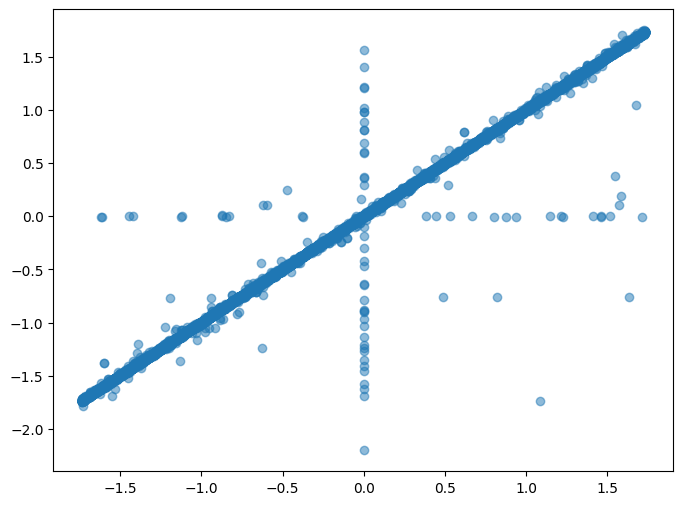

In [31]:
#Plotting the predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

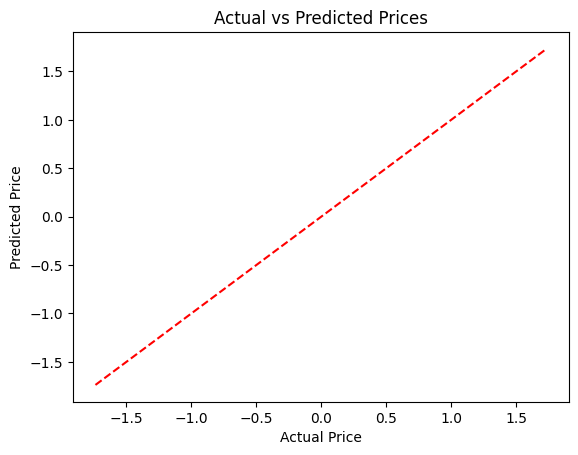

In [32]:
# Ploting the line of perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

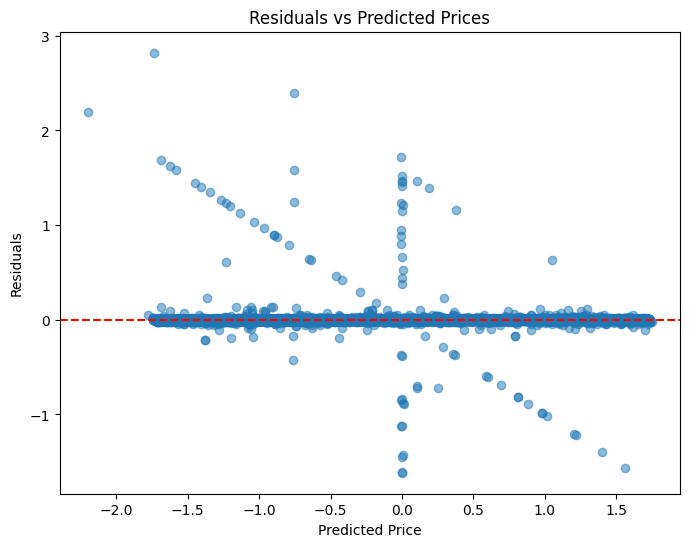

In [33]:
# Plotting the residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Prices')
plt.show()

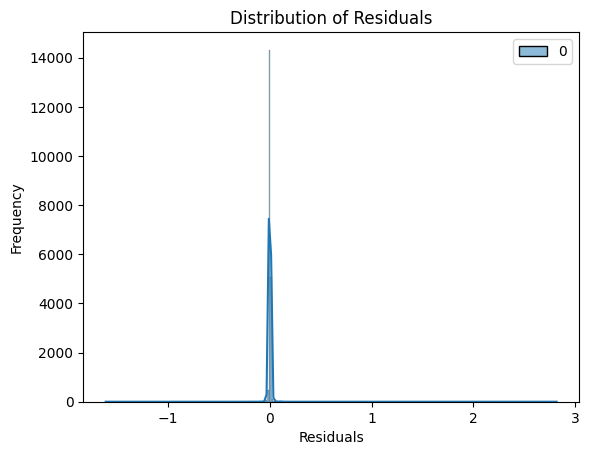

In [42]:
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

## Now similarly applying ridge and lasso regression

Lasso Regression - Mean Absolute Error: 0.09108299906613998
Lasso Regression - Mean Squared Error: 0.014112600206026714
Lasso Regression - Root Mean Squared Error: 0.11879646546100063
Lasso Regression - R-squared: 0.985819023526983


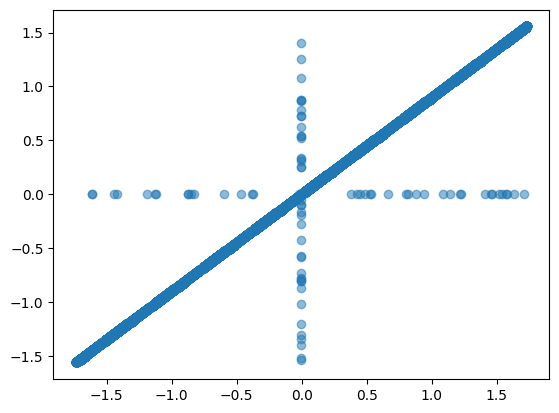

In [36]:
#Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'Lasso Regression - Mean Absolute Error: {mae_lasso}')
print(f'Lasso Regression - Mean Squared Error: {mse_lasso}')
print(f'Lasso Regression - Root Mean Squared Error: {rmse_lasso}')
print(f'Lasso Regression - R-squared: {r2_lasso}')
plt.scatter(y_test, y_pred_lasso, alpha=0.5)

Here we can see that error increases as compared to linear regression 

/Users/devammpatel/Desktop/Supervised ML Project on Airbnb Dataset/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LassoCV Regression - Mean Absolute Error: 0.007823840799861132
LassoCV Regression - Mean Squared Error: 0.004124724006037456
LassoCV Regression - Root Mean Squared Error: 0.06422401424730048
LassoCV Regression - R-squared: 0.9958552914960117


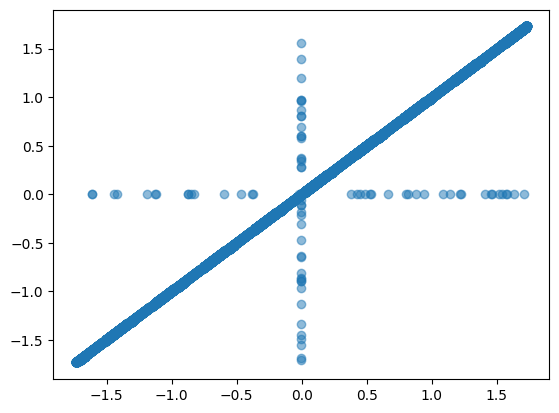

In [37]:
#LassoCV Regression
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lasso_cv_model = LassoCV(cv=5)
lasso_cv_model.fit(X_train, y_train)
y_pred_lasso_cv = lasso_cv_model.predict(X_test)
mae_lasso_cv = mean_absolute_error(y_test, y_pred_lasso_cv)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
rmse_lasso_cv = np.sqrt(mse_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
print(f'LassoCV Regression - Mean Absolute Error: {mae_lasso_cv}')
print(f'LassoCV Regression - Mean Squared Error: {mse_lasso_cv}')
print(f'LassoCV Regression - Root Mean Squared Error: {rmse_lasso_cv}')
print(f'LassoCV Regression - R-squared: {r2_lasso_cv}')
plt.scatter(y_test, y_pred_lasso_cv, alpha=0.5)

Ridge Regression - Mean Absolute Error: 0.009131265892723473
Ridge Regression - Mean Squared Error: 0.0046714667774693346
Ridge Regression - Root Mean Squared Error: 0.0683481292901959
Ridge Regression - R-squared: 0.9953058997279974


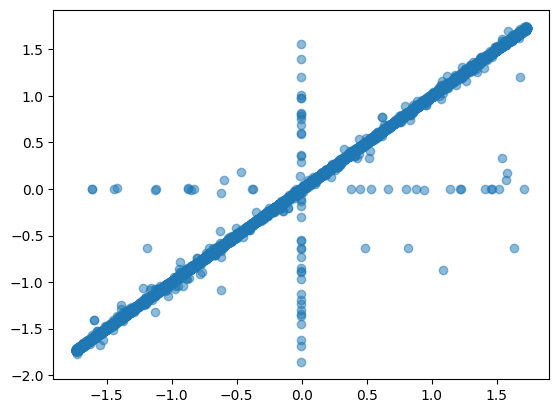

In [38]:
#Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Regression - Mean Absolute Error: {mae_ridge}')
print(f'Ridge Regression - Mean Squared Error: {mse_ridge}')
print(f'Ridge Regression - Root Mean Squared Error: {rmse_ridge}')
print(f'Ridge Regression - R-squared: {r2_ridge}')
plt.scatter(y_test, y_pred_ridge, alpha=0.5)

RidgeCV Regression - Mean Absolute Error: 0.0086747390146998
RidgeCV Regression - Mean Squared Error: 0.00419886333717103
RidgeCV Regression - Root Mean Squared Error: 0.06479863684654971
RidgeCV Regression - R-squared: 0.9957807929560417


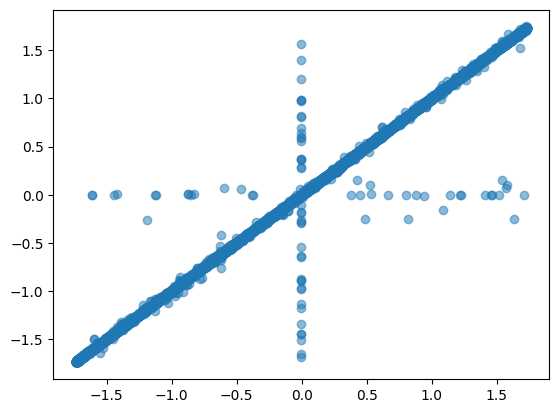

In [39]:
#RidgeCV Regression
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
ridge_cv_model = RidgeCV(cv=5)
ridge_cv_model.fit(X_train, y_train)
y_pred_ridge_cv = ridge_cv_model.predict(X_test)
mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
rmse_ridge_cv = np.sqrt(mse_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
print(f'RidgeCV Regression - Mean Absolute Error: {mae_ridge_cv}')
print(f'RidgeCV Regression - Mean Squared Error: {mse_ridge_cv}')
print(f'RidgeCV Regression - Root Mean Squared Error: {rmse_ridge_cv}')
print(f'RidgeCV Regression - R-squared: {r2_ridge_cv}')
plt.scatter(y_test, y_pred_ridge_cv, alpha=0.5)

ElasticNet Regression - Mean Absolute Error: 0.08690901612945748
ElasticNet Regression - Mean Squared Error: 0.013165639935196479
ElasticNet Regression - Root Mean Squared Error: 0.11474162250550791
ElasticNet Regression - R-squared: 0.9867705718685701


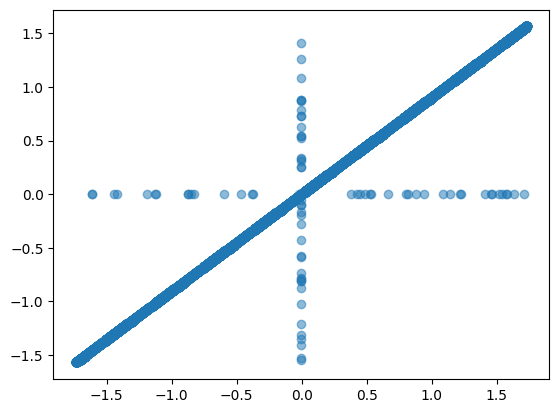

In [40]:
#ElasticNet Regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net_model.fit(X_train, y_train) 
y_pred_elastic_net = elastic_net_model.predict(X_test)
mae_elastic_net = mean_absolute_error(y_test, y_pred_elastic_net)
mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
rmse_elastic_net = np.sqrt(mse_elastic_net)
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)
print(f'ElasticNet Regression - Mean Absolute Error: {mae_elastic_net}')
print(f'ElasticNet Regression - Mean Squared Error: {mse_elastic_net}')
print(f'ElasticNet Regression - Root Mean Squared Error: {rmse_elastic_net}')
print(f'ElasticNet Regression - R-squared: {r2_elastic_net}')
plt.scatter(y_test, y_pred_elastic_net, alpha=0.5)

/Users/devammpatel/Desktop/Supervised ML Project on Airbnb Dataset/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


ElasticNetCV Regression - Mean Absolute Error: 0.008340547581304198
ElasticNetCV Regression - Mean Squared Error: 0.004128698193679962
ElasticNetCV Regression - Root Mean Squared Error: 0.06425494684209117
ElasticNetCV Regression - R-squared: 0.9958512980532276


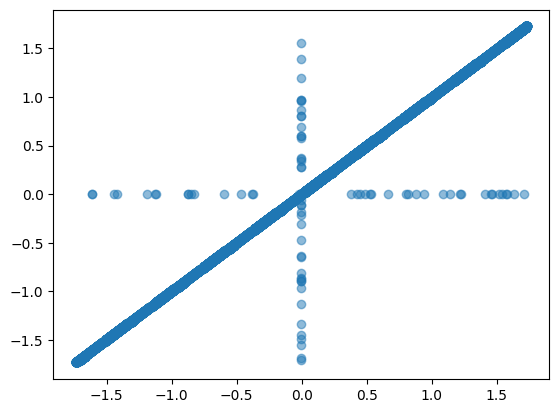

In [41]:
#ElasticNetCV Regression
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
elastic_net_cv_model = ElasticNetCV(cv=5, l1_ratio=0.5)
elastic_net_cv_model.fit(X_train, y_train)
y_pred_elastic_net_cv = elastic_net_cv_model.predict(X_test)
mae_elastic_net_cv = mean_absolute_error(y_test, y_pred_elastic_net_cv)
mse_elastic_net_cv = mean_squared_error(y_test, y_pred_elastic_net_cv)
rmse_elastic_net_cv = np.sqrt(mse_elastic_net_cv)
r2_elastic_net_cv = r2_score(y_test, y_pred_elastic_net_cv)
print(f'ElasticNetCV Regression - Mean Absolute Error: {mae_elastic_net_cv}')
print(f'ElasticNetCV Regression - Mean Squared Error: {mse_elastic_net_cv}')
print(f'ElasticNetCV Regression - Root Mean Squared Error: {rmse_elastic_net_cv}')
print(f'ElasticNetCV Regression - R-squared: {r2_elastic_net_cv}')
plt.scatter(y_test, y_pred_elastic_net_cv, alpha=0.5)

#### Amongst all the model tested till now, ElasticNet gives the best prediction outcome 